# IT Ticket Classification — Extended Models
**CS 593 | komas02**

Extends the DistilBERT baseline (Macro-F1: **0.8888**) with five new experiments:

| # | Model | Why |
|---|---|---|
| 1 | `microsoft/deberta-v3-base` | Current SOTA for short-text classification; disentangled attention |
| 2 | `roberta-base` | Stronger BERT variant; more robust pre-training |
| 3 | `XGBoost + TF-IDF` | Strong gradient-boosted baseline; nonlinear interactions on TF-IDF features |
| 4 | `SetFit` (paraphrase-mpnet) | Few-shot sentence transformer; fast contrastive fine-tuning |
| 5 | Ensemble (multiple combinations) | Average probabilities of trained models |

**Dataset:** `all_tickets_processed_improved_v3.csv` — 40,777 tickets, 7 categories, English (~97%)  
**Split:** 70% train / 15% val / 15% test (stratified, random_state=42)  
**Primary metric:** Macro-F1

---
**Before running:** Upload `all_tickets_processed_improved_v3.csv` to your Colab session  
(Runtime → Change runtime type → T4 GPU)

In [2]:
# Run once to install required packages
!pip install -q transformers datasets sentencepiece accelerate xgboost setfit
print("packages ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
packages ready


In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

from xgboost import XGBClassifier

import torch
from torch.nn import CrossEntropyLoss

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print("Device: Apple MPS")
else:
    DEVICE = "cpu"
    print("WARNING: No GPU found — transformer training will be very slow")

print("imports done")

GPU: Tesla T4
imports done


## Configuration
All tuneable constants in one place.

In [4]:
# ── Dataset ──────────────────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/shreyakb/test123/all_tickets_processed_improved_v3.csv"
TEXT_COL     = "Document"
LABEL_COL    = "Topic_group"
DROP_LABEL   = "Miscellaneous"   # set to None to keep all labels
RANDOM_STATE = 42

# ── Training ─────────────────────────────────────────────────────────────────
NUM_EPOCHS   = 3
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_LENGTH   = 128    # tickets are short; 90th pct of token length is ~67

# Batch sizes — DeBERTa and RoBERTa are larger than DistilBERT
# gradient_accumulation keeps effective batch = 16 for all models
BATCH_SM = 16   # DistilBERT
BATCH_LG =  8   # DeBERTa / RoBERTa
GRAD_ACC =  2   # used with BATCH_LG → effective batch of 16

# ── Models ───────────────────────────────────────────────────────────────────
# Dataset is 97.2% English → use English-specific models (stronger than multilingual)
DISTILBERT_NAME = "distilbert-base-uncased"
DEBERTA_NAME    = "microsoft/deberta-v3-base"   # requires sentencepiece
ROBERTA_NAME    = "roberta-base"

print("config set")
print(f"  models: {DISTILBERT_NAME} | {DEBERTA_NAME} | {ROBERTA_NAME}")
print(f"  epochs: {NUM_EPOCHS} | lr: {LR} | max_len: {MAX_LENGTH}")

# ── XGBoost ──────────────────────────────────────────────────────────────────
XGB_N_ESTIMATORS = 500
XGB_MAX_DEPTH    = 7
XGB_LR           = 0.1
XGB_SUBSAMPLE    = 0.8

print("config set")

config set
  models: distilbert-base-uncased | microsoft/deberta-v3-base | roberta-base
  epochs: 3 | lr: 2e-05 | max_len: 128
config set


## 1. Data Loading & Preprocessing

In [5]:
df_raw = pd.read_csv(DATASET_PATH)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
print("\nLabel distribution (raw):")
print(df_raw[LABEL_COL].value_counts())

Raw shape: (47837, 2)
Columns: ['Document', 'Topic_group']

Label distribution (raw):
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [6]:
df = df_raw.copy()

# Drop the ambiguous Miscellaneous label
if DROP_LABEL:
    df = df[df[LABEL_COL] != DROP_LABEL].reset_index(drop=True)
    print(f"Dropped '{DROP_LABEL}' → {len(df)} tickets remain")

# Build unified text and label columns
df["text"]  = df[TEXT_COL].fillna("").str.strip()
df["label"] = df[LABEL_COL].str.strip()

df = df.dropna(subset=["text", "label"])
df = df[df["text"] != ""].reset_index(drop=True)

print(f"Working dataset: {df.shape}")
print("\nLabel distribution:")
print(df["label"].value_counts())

Dropped 'Miscellaneous' → 40777 tickets remain
Working dataset: (40777, 4)

Label distribution:
label
Hardware                 13617
HR Support               10915
Access                    7125
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


## 2. Train / Val / Test Split (70 / 15 / 15, stratified)

In [7]:
train_df, temp_df = train_test_split(
    df[["text", "label"]],
    test_size=0.30,
    stratify=df["label"],
    random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df["label"].value_counts())

Train: 28543 | Val: 6117 | Test: 6117

Train label distribution:
label
Hardware                 9532
HR Support               7640
Access                   4987
Storage                  1944
Purchase                 1725
Internal Project         1483
Administrative rights    1232
Name: count, dtype: int64


## 3. Baseline Models (TF-IDF)
Reproduce the LR and NB baselines from the original project for a clean reference point.

In [8]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", C=10))
])
lr_pipeline.fit(train_df["text"], train_df["label"])
lr_preds = lr_pipeline.predict(test_df["text"])

lr_acc = accuracy_score(test_df["label"], lr_preds)
lr_f1  = f1_score(test_df["label"], lr_preds, average="macro")
print(f"Logistic Regression  →  Accuracy: {lr_acc:.4f}  |  Macro-F1: {lr_f1:.4f}")
print(classification_report(test_df["label"], lr_preds, digits=4))

Logistic Regression  →  Accuracy: 0.8879  |  Macro-F1: 0.8826
                       precision    recall  f1-score   support

               Access     0.9049    0.9083    0.9066      1069
Administrative rights     0.7457    0.8220    0.7820       264
           HR Support     0.8962    0.8864    0.8913      1637
             Hardware     0.8799    0.8790    0.8795      2042
     Internal Project     0.8800    0.8994    0.8896       318
             Purchase     0.9417    0.9162    0.9288       370
              Storage     0.9095    0.8921    0.9007       417

             accuracy                         0.8879      6117
            macro avg     0.8797    0.8862    0.8826      6117
         weighted avg     0.8886    0.8879    0.8881      6117



In [9]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ("clf",   MultinomialNB(alpha=0.1))
])
nb_pipeline.fit(train_df["text"], train_df["label"])
nb_preds = nb_pipeline.predict(test_df["text"])

nb_acc = accuracy_score(test_df["label"], nb_preds)
nb_f1  = f1_score(test_df["label"], nb_preds, average="macro")
print(f"Naive Bayes          →  Accuracy: {nb_acc:.4f}  |  Macro-F1: {nb_f1:.4f}")

Naive Bayes          →  Accuracy: 0.8257  |  Macro-F1: 0.8000


## 4. Transformer Setup — Shared Utilities

In [10]:
# Label encoding
label_list = sorted(df["label"].unique())
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}
print("Classes:", label_list)
print("label2id:", label2id)

# Class weights (balanced) — same method used for LR and original DistilBERT
y_train_numeric = train_df["label"].map(label2id).values
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_list)),
    y=y_train_numeric
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)
print("\nClass weights:", dict(zip(label_list, class_weights_np.round(3))))

Classes: ['Access', 'Administrative rights', 'HR Support', 'Hardware', 'Internal Project', 'Purchase', 'Storage']
label2id: {'Access': 0, 'Administrative rights': 1, 'HR Support': 2, 'Hardware': 3, 'Internal Project': 4, 'Purchase': 5, 'Storage': 6}

Class weights: {'Access': np.float64(0.818), 'Administrative rights': np.float64(3.31), 'HR Support': np.float64(0.534), 'Hardware': np.float64(0.428), 'Internal Project': np.float64(2.75), 'Purchase': np.float64(2.364), 'Storage': np.float64(2.098)}


In [11]:
# Extract probability outputs from sklearn models, aligned to label_list order.
# sklearn's predict_proba columns follow pipeline.classes_, which may differ
# from label_list — reindex to guarantee they match before using in ensemble.
def get_sklearn_probs(pipeline, texts, label_list):
    raw   = pipeline.predict_proba(texts)
    order = [list(pipeline.named_steps["clf"].classes_).index(l) for l in label_list]
    return raw[:, order]

lr_probs = get_sklearn_probs(lr_pipeline, test_df["text"], label_list)
nb_probs = get_sklearn_probs(nb_pipeline, test_df["text"], label_list)

print(f"LR probs shape: {lr_probs.shape}  |  row sums (should be 1): {lr_probs.sum(axis=1)[:3].round(4)}")
print(f"NB probs shape: {nb_probs.shape}  |  row sums: {nb_probs.sum(axis=1)[:3].round(4)}")

LR probs shape: (6117, 7)  |  row sums (should be 1): [1. 1. 1.]
NB probs shape: (6117, 7)  |  row sums: [1. 1. 1.]


## 4b. Model: XGBoost + TF-IDF
`XGBClassifier` on the same TF-IDF features as LR and NB.  
Uses `gpu_hist` on CUDA, falls back to `hist` on CPU.  
~3–5 min on T4 GPU. Early stopping on validation loss.

Placed here (after label encoding) so label2id and class_weights_np are available.

In [12]:
import time
from xgboost import XGBClassifier

# ── Shared TF-IDF vectorizer (fit on train only) ──────────────────────────
xgb_vec = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_xgb = xgb_vec.fit_transform(train_df['text'])
X_val_xgb   = xgb_vec.transform(val_df['text'])
X_test_xgb  = xgb_vec.transform(test_df['text'])

# Label encoding — XGBoost needs integer labels
y_train_xgb = train_df['label'].map(label2id).values
y_val_xgb   = val_df['label'].map(label2id).values
y_test_xgb  = test_df['label'].map(label2id).values

# Class weights for imbalance — mirror the balanced approach used everywhere else
xgb_sample_weights = np.array(
    [class_weights_np[y] for y in y_train_xgb], dtype=np.float32
)

xgb_clf = XGBClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH,
    learning_rate=XGB_LR,
    subsample=XGB_SUBSAMPLE,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda' if DEVICE == 'cuda' else 'cpu',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=1,
)
t0 = time.time()
xgb_clf.fit(
    X_train_xgb, y_train_xgb,
    sample_weight=xgb_sample_weights,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=50,
)
xgb_time = time.time() - t0

# Predictions and probabilities
xgb_pred_ids = xgb_clf.predict(X_test_xgb)
xgb_preds    = [id2label[p] for p in xgb_pred_ids]

# predict_proba columns follow 0..N in label2id order, which matches label_list
xgb_probs = xgb_clf.predict_proba(X_test_xgb)  # shape (N, 7)

xgb_acc = accuracy_score(test_df['label'], xgb_preds)
xgb_f1  = f1_score(test_df['label'], xgb_preds, average='macro')

print(f'\nXGBoost + TF-IDF  →  Accuracy: {xgb_acc:.4f}  |  Macro-F1: {xgb_f1:.4f}')
print(f'Training time: {xgb_time:.0f}s ({xgb_time/60:.1f} min)')
print(classification_report(test_df['label'], xgb_preds, digits=4))

[0]	validation_0-mlogloss:2.63730
[50]	validation_0-mlogloss:27.78967
[100]	validation_0-mlogloss:27.78967
[150]	validation_0-mlogloss:27.78967
[200]	validation_0-mlogloss:27.78967
[250]	validation_0-mlogloss:27.78967
[300]	validation_0-mlogloss:27.78967
[350]	validation_0-mlogloss:27.78967
[400]	validation_0-mlogloss:27.78967
[450]	validation_0-mlogloss:27.78967
[499]	validation_0-mlogloss:27.78967

XGBoost + TF-IDF  →  Accuracy: 0.1949  |  Macro-F1: 0.1144
Training time: 23s (0.4 min)
                       precision    recall  f1-score   support

               Access     0.0000    0.0000    0.0000      1069
Administrative rights     0.0000    0.0000    0.0000       264
           HR Support     0.5488    0.0275    0.0524      1637
             Hardware     0.4226    0.3090    0.3570      2042
     Internal Project     0.0000    0.0000    0.0000       318
             Purchase     0.1485    0.8838    0.2543       370
              Storage     0.0808    0.4532    0.1371       417

  

In [13]:
class WeightedTrainer(Trainer):
    """Overrides loss to use class-weighted cross-entropy."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        # Match both device AND dtype — DeBERTa-v3 outputs Half internally
        # even when fp16=False, so weights must follow the logits' dtype.
        weights = self.class_weights.to(device=logits.device, dtype=logits.dtype)
        loss    = CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [14]:
def tokenize_datasets(model_name, train_df, val_df, test_df, label2id, max_length):
    """Tokenize all three splits for a given model. Returns HF Datasets."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    sample = train_df["text"].sample(min(500, len(train_df)), random_state=42).tolist()
    lens   = [len(tokenizer(t, truncation=False)["input_ids"]) for t in sample]
    print(f"  [{model_name}] token length — median: {np.median(lens):.0f}, "
          f"90th pct: {np.percentile(lens, 90):.0f}, max sample: {max(lens)}")

    def encode_labels(df):
        out = df.copy()
        out["label"] = out["label"].map(label2id)
        return out

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    splits = {}
    for name, df_split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        ds = Dataset.from_pandas(encode_labels(df_split).reset_index(drop=True))
        ds = ds.map(tokenize_batch, batched=True)
        keep = ["input_ids", "attention_mask", "label"]
        if "token_type_ids" in ds.column_names:
            keep.append("token_type_ids")
        ds = ds.remove_columns([c for c in ds.column_names if c not in keep])
        ds.set_format("torch")
        splits[name] = ds

    return splits["train"], splits["val"], splits["test"], tokenizer


def run_transformer(
    model_name, output_dir,
    train_ds, val_ds, test_ds,
    tokenizer,
    class_weights, label_list, label2id, id2label,
    num_epochs=NUM_EPOCHS, lr=LR,
    batch_size=BATCH_SM, grad_acc=1,
    use_fp16=None  # None = auto (True on CUDA). Set False for DeBERTa-v3.
):
    """
    Fine-tune model_name and return:
      (preds_str, probabilities, test_macro_f1, test_accuracy, elapsed_sec)

    DeBERTa-v3 note: use_fp16=False is required. The model also runs its
    forward pass in Half internally even when fp16=False, which causes NaN
    gradients without the AMP scaler. Fix: call model.float() after loading
    to force the entire forward pass into float32.
    """
    if use_fp16 is None:
        use_fp16 = (DEVICE == "cuda")

    print(f"\n{'='*60}")
    print(f" Training: {model_name}")
    print(f" fp16: {use_fp16}  |  batch: {batch_size}  |  grad_acc: {grad_acc}")
    print(f"{'='*60}")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_list),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    # DeBERTa-v3 uses Half precision in its forward pass regardless of the
    # fp16 training flag. Without the AMP gradient scaler (fp16=False), those
    # Half-precision gradients overflow → NaN → model collapse.
    # Forcing float32 eliminates the Half forward pass entirely.
    if not use_fp16:
        model = model.float()
        print("  model cast to float32 (required for stable fp16=False training)")

    total_steps  = (len(train_ds) // (batch_size * grad_acc)) * num_epochs
    warmup_steps = int(WARMUP_RATIO * total_steps)
    print(f"  total steps: {total_steps} | warmup: {warmup_steps}")

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        gradient_accumulation_steps=grad_acc,
        warmup_steps=warmup_steps,
        weight_decay=WEIGHT_DECAY,
        learning_rate=lr,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        fp16=use_fp16
    )

    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0

    pred_out  = trainer.predict(test_ds)
    logits    = pred_out.predictions
    probs     = softmax(logits, axis=1)
    preds_num = np.argmax(probs, axis=1)
    preds_str = [id2label[p] for p in preds_num]
    true_str  = [id2label[l] for l in pred_out.label_ids]

    macro_f1 = f1_score(true_str, preds_str, average="macro")
    acc      = accuracy_score(true_str, preds_str)

    print(f"\n  Test Accuracy: {acc:.4f}  |  Macro-F1: {macro_f1:.4f}")
    print(f"  Training time: {elapsed:.0f}s ({elapsed/60:.1f} min)")
    print(classification_report(true_str, preds_str, digits=4))

    return preds_str, probs, macro_f1, acc, elapsed


print("helper functions defined")

helper functions defined


## 5. Model 1 — DistilBERT (Baseline Transformer)
`distilbert-base-uncased` — 66M parameters, ~7 min on T4  
Re-running to get probabilities for the ensemble and a clean reference.

In [15]:
print("Tokenizing for DistilBERT...")
distilbert_train_ds, distilbert_val_ds, distilbert_test_ds, distilbert_tok = tokenize_datasets(
    DISTILBERT_NAME, train_df, val_df, test_df, label2id, MAX_LENGTH
)
print("done")

Tokenizing for DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  [distilbert-base-uncased] token length — median: 31, 90th pct: 92, max sample: 961


Map:   0%|          | 0/28543 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

done


In [16]:
distilbert_preds, distilbert_probs, distilbert_f1, distilbert_acc, distilbert_time = run_transformer(
    model_name=DISTILBERT_NAME,
    output_dir="./ckpt_distilbert",
    train_ds=distilbert_train_ds,
    val_ds=distilbert_val_ds,
    test_ds=distilbert_test_ds,
    tokenizer=distilbert_tok,
    class_weights=class_weights,
    label_list=label_list,
    label2id=label2id,
    id2label=id2label,
    batch_size=BATCH_SM,
    grad_acc=1
)


 Training: distilbert-base-uncased
 fp16: True  |  batch: 16  |  grad_acc: 1


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  total steps: 5349 | warmup: 534


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



  Test Accuracy: 0.8867  |  Macro-F1: 0.8778
  Training time: 667s (11.1 min)
                       precision    recall  f1-score   support

               Access     0.8769    0.9392    0.9070      1069
Administrative rights     0.6847    0.8636    0.7638       264
           HR Support     0.9054    0.8943    0.8998      1637
             Hardware     0.9173    0.8364    0.8750      2042
     Internal Project     0.8512    0.8994    0.8746       318
             Purchase     0.9134    0.9405    0.9268       370
              Storage     0.8713    0.9257    0.8977       417

             accuracy                         0.8867      6117
            macro avg     0.8600    0.8999    0.8778      6117
         weighted avg     0.8902    0.8867    0.8871      6117



## 6. Model 2 — DeBERTa-v3-base
`microsoft/deberta-v3-base` — 86M parameters  
Uses disentangled attention + replaced token detection pre-training.  
Consistently the strongest single model on text classification benchmarks (2023–2025).  
~12–15 min on T4 with batch_size=8 + gradient_accumulation=2.

In [17]:
print("Tokenizing for DeBERTa...")
deberta_train_ds, deberta_val_ds, deberta_test_ds, deberta_tok = tokenize_datasets(
    DEBERTA_NAME, train_df, val_df, test_df, label2id, MAX_LENGTH
)
print("done")

Tokenizing for DeBERTa...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

  [microsoft/deberta-v3-base] token length — median: 28, 90th pct: 84, max sample: 931


Map:   0%|          | 0/28543 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

done


In [18]:
deberta_preds, deberta_probs, deberta_f1, deberta_acc, deberta_time = run_transformer(
    model_name=DEBERTA_NAME,
    output_dir="./ckpt_deberta",
    train_ds=deberta_train_ds,
    val_ds=deberta_val_ds,
    test_ds=deberta_test_ds,
    tokenizer=deberta_tok,
    class_weights=class_weights,
    label_list=label_list,
    label2id=label2id,
    id2label=id2label,
    batch_size=BATCH_LG,
    grad_acc=GRAD_ACC,
    use_fp16=False   # DeBERTa-v3 StableEmbedding uses FP32 params; fp16 grad scaler conflicts
)


 Training: microsoft/deberta-v3-base
 fp16: False  |  batch: 8  |  grad_acc: 2


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


  Test Accuracy: 0.8588  |  Macro-F1: 0.8495
  Training time: 2299s (38.3 min)
                       precision    recall  f1-score   support

               Access     0.8832    0.9055    0.8942      1069
Administrative rights     0.6257    0.8485    0.7203       264
           HR Support     0.8912    0.8656    0.8782      1637
             Hardware     0.8823    0.7963    0.8371      2042
     Internal Project     0.7572    0.9119    0.8274       318
             Purchase     0.9394    0.9216    0.9304       370
              Storage     0.7996    0.9281    0.8590       417

             accuracy                         0.8588      6117
            macro avg     0.8255    0.8825    0.8495      6117
         weighted avg     0.8651    0.8588    0.8597      6117



## 7. Model 3 — RoBERTa-base
`roberta-base` — 125M parameters  
Same architecture as BERT but trained on 10× more data with dynamic masking — no NSP objective.  
~10–12 min on T4 with batch_size=8 + gradient_accumulation=2.

In [19]:
print("Tokenizing for RoBERTa...")
roberta_train_ds, roberta_val_ds, roberta_test_ds, roberta_tok = tokenize_datasets(
    ROBERTA_NAME, train_df, val_df, test_df, label2id, MAX_LENGTH
)
print("done")

Tokenizing for RoBERTa...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  [roberta-base] token length — median: 31, 90th pct: 88, max sample: 944


Map:   0%|          | 0/28543 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

Map:   0%|          | 0/6117 [00:00<?, ? examples/s]

done


In [20]:
roberta_preds, roberta_probs, roberta_f1, roberta_acc, roberta_time = run_transformer(
    model_name=ROBERTA_NAME,
    output_dir="./ckpt_roberta",
    train_ds=roberta_train_ds,
    val_ds=roberta_val_ds,
    test_ds=roberta_test_ds,
    tokenizer=roberta_tok,
    class_weights=class_weights,
    label_list=label_list,
    label2id=label2id,
    id2label=id2label,
    batch_size=BATCH_LG,
    grad_acc=GRAD_ACC
)


 Training: roberta-base
 fp16: True  |  batch: 8  |  grad_acc: 2


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  total steps: 5349 | warmup: 534


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  Test Accuracy: 0.8890  |  Macro-F1: 0.8814
  Training time: 1644s (27.4 min)
                       precision    recall  f1-score   support

               Access     0.8816    0.9336    0.9069      1069
Administrative rights     0.6994    0.8636    0.7729       264
           HR Support     0.9001    0.9023    0.9012      1637
             Hardware     0.9208    0.8364    0.8766      2042
     Internal Project     0.8319    0.9025    0.8658       318
             Purchase     0.9380    0.9405    0.9393       370
              Storage     0.8770    0.9400    0.9074       417

             accuracy                         0.8890      6117
            macro avg     0.8641    0.9027    0.8814      6117
         weighted avg     0.8923    0.8890    0.8893      6117



## 8. Model 4 — SetFit (Few-Shot Sentence Transformer)
SetFit fine-tunes a sentence transformer with contrastive learning on labeled pairs.  
No need for a GPU-intensive fine-tuning loop — runs in minutes.  

Two modes controlled by `SETFIT_FEW_SHOT`:
- `False` → full training set (fair comparison with other models)
- `True`  → `SETFIT_N_PER_CLASS` examples per class (demonstrates data efficiency)

Model: `paraphrase-mpnet-base-v2` (strong general-purpose sentence encoder, 110M params)

In [21]:
!pip install -U setfit huggingface_hub datasets sentence-transformers transformers

Found existing installation: setfit 1.1.3
Uninstalling setfit-1.1.3:
  Successfully uninstalled setfit-1.1.3
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: sentence-transformers 5.2.3
Uninstalling sentence-transformers-5.2.3:
  Successfully uninstalled sentence-transformers-5.2.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.9 MB/s eta 0:00:0000:01:00:01


In [23]:
!pip install -U setfit huggingface_hub datasets sentence-transformers transformers

  Using cached setfit-1.1.3-py3-none-any.whl.metadata (12 kB)
Using cached setfit-1.1.3-py3-none-any.whl (75 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 14.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 94.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Fo

In [ ]:
from setfit import SetFitModel, SetFitTrainer
from datasets import Dataset as HFDataset

SETFIT_FEW_SHOT   = False   # True = few-shot demo; False = full train set
SETFIT_N_PER_CLASS = 64     # examples per class when SETFIT_FEW_SHOT=True
SETFIT_MODEL_NAME  = 'sentence-transformers/paraphrase-mpnet-base-v2'

# ── Training data ─────────────────────────────────────────────────────────
if SETFIT_FEW_SHOT:
    shots = (
        train_df
        .groupby('label', group_keys=False)
        .apply(lambda x: x.sample(min(SETFIT_N_PER_CLASS, len(x)), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
    setfit_train_df = shots
    print(f'SetFit few-shot: {SETFIT_N_PER_CLASS} per class → {len(setfit_train_df)} total')
else:
    setfit_train_df = train_df
    print(f'SetFit full train: {len(setfit_train_df)} examples')

# HuggingFace Dataset expects integer labels
setfit_train_ds = HFDataset.from_dict({
    'text':  setfit_train_df['text'].tolist(),
    'label': setfit_train_df['label'].map(label2id).tolist(),
})
setfit_test_ds = HFDataset.from_dict({
    'text':  test_df['text'].tolist(),
    'label': test_df['label'].map(label2id).tolist(),
})

# ── Model & Trainer ───────────────────────────────────────────────────────
setfit_model = SetFitModel.from_pretrained(
    SETFIT_MODEL_NAME,
    num_classes=len(label_list),
    multi_target_strategy=None,
)

setfit_trainer = SetFitTrainer(
    model=setfit_model,
    train_dataset=setfit_train_ds,
    eval_dataset=setfit_test_ds,
    metric='accuracy',
    batch_size=32,
    num_iterations=20,      # contrastive pairs generated per class
    num_epochs=1,           # epochs for the contrastive embedding phase
    column_mapping={'text': 'text', 'label': 'label'},
)

t0 = time.time()
setfit_trainer.train()
setfit_time = time.time() - t0

# ── Predictions and probabilities ─────────────────────────────────────────
setfit_pred_ids = np.array(setfit_model.predict(test_df['text'].tolist()))
setfit_preds    = [id2label[int(p)] for p in setfit_pred_ids]

# predict_proba: shape (N, num_classes), columns in label2id order
setfit_probs = np.array(setfit_model.predict_proba(test_df['text'].tolist()))

setfit_acc = accuracy_score(test_df['label'], setfit_preds)
setfit_f1  = f1_score(test_df['label'], setfit_preds, average='macro')

mode_label = f'few-shot ({SETFIT_N_PER_CLASS}/class)' if SETFIT_FEW_SHOT else 'full train'
print(f'\nSetFit [{mode_label}]  →  Accuracy: {setfit_acc:.4f}  |  Macro-F1: {setfit_f1:.4f}')
print(f'Training time: {setfit_time:.0f}s ({setfit_time/60:.1f} min)')
print(classification_report(test_df['label'], setfit_preds, digits=4))

## 8. Ensemble — Average Logit Probabilities
Average the softmax probabilities from all three fine-tuned transformers.  
No additional training needed — runs in milliseconds.  
Each model's vote is weighted equally; modify the weights below if one model dominates on validation.

In [32]:
true_labels = test_df['label'].tolist()

def make_ensemble(prob_dict, y_true, name):
    """Average a dict of {label: prob_array} and return (preds, probs, f1, acc)."""
    avg = np.mean(list(prob_dict.values()), axis=0)
    preds = [id2label[p] for p in np.argmax(avg, axis=1)]
    f1  = f1_score(y_true, preds, average='macro')
    acc = accuracy_score(y_true, preds)
    print(f"{name:<45} Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    return preds, avg, f1, acc

print('─' * 75)
print(f"{'Ensemble variant':<45} {'Accuracy':>10}  {'Macro-F1':>9}")
print('─' * 75)

# Transformer-only ensembles
ensemble_preds, ensemble_probs, ensemble_f1, ensemble_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'deberta': deberta_probs, 'roberta': roberta_probs},
    true_labels, 'Transformer ensemble (DB+DE+RB)'
)

ensemble_dr_preds, ensemble_dr_probs, ensemble_dr_f1, ensemble_dr_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs},
    true_labels, 'DistilBERT + RoBERTa'
)

# Add XGBoost to ensemble (it captures keyword patterns LR and NB also capture,
# but with nonlinear interactions that may be complementary to transformers)
ensemble_xgb_preds, ensemble_xgb_probs, ensemble_xgb_f1, ensemble_xgb_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs, 'xgb': xgb_probs},
    true_labels, 'DistilBERT + RoBERTa + XGB'
)

# Original best combinations (LR + NB)
ensemble_lr_preds, ensemble_lr_probs, ensemble_lr_f1, ensemble_lr_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'deberta': deberta_probs,
     'roberta': roberta_probs, 'lr': lr_probs},
    true_labels, 'Transformers + LR'
)

ensemble_drl_preds, ensemble_drl_probs, ensemble_drl_f1, ensemble_drl_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs, 'lr': lr_probs},
    true_labels, 'DistilBERT + RoBERTa + LR'
)

ensemble_all_preds, ensemble_all_probs, ensemble_all_f1, ensemble_all_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'deberta': deberta_probs,
     'roberta': roberta_probs, 'lr': lr_probs, 'nb': nb_probs},
    true_labels, 'All 5 (Transformers + LR + NB)'
)

ensemble_best_preds, ensemble_best_probs, ensemble_best_f1, ensemble_best_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs,
     'lr': lr_probs, 'nb': nb_probs},
    true_labels, 'DistilBERT + RoBERTa + LR + NB'
)

# New combinations including XGBoost
ensemble_xgb_lr_preds, ensemble_xgb_lr_probs, ensemble_xgb_lr_f1, ensemble_xgb_lr_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs,
     'lr': lr_probs, 'xgb': xgb_probs},
    true_labels, 'DB + RB + LR + XGB'
)

ensemble_xgb_all_preds, ensemble_xgb_all_probs, ensemble_xgb_all_f1, ensemble_xgb_all_acc = make_ensemble(
    {'distilbert': distilbert_probs, 'roberta': roberta_probs,
     'lr': lr_probs, 'nb': nb_probs, 'xgb': xgb_probs},
    true_labels, 'DB + RB + LR + NB + XGB'
)

# # SetFit ensemble
# ensemble_setfit_preds, ensemble_setfit_probs, ensemble_setfit_f1, ensemble_setfit_acc = make_ensemble(
#     {'distilbert': distilbert_probs, 'roberta': roberta_probs,}
#      # 'setfit': setfit_probs, 'lr': lr_probs},
#     true_labels, 'DB + RB + SetFit + LR'
# )

print('─' * 75)
all_variants = [
    ('Transformer (DB+DE+RB)',     ensemble_f1),
    ('DistilBERT + RoBERTa',       ensemble_dr_f1),
    ('Transformers + LR',          ensemble_lr_f1),
    ('DistilBERT + RoBERTa + LR',  ensemble_drl_f1),
    ('All 5',                      ensemble_all_f1),
    ('DB + RB + LR + NB',          ensemble_best_f1),
    ('DB + RB + XGB',              ensemble_xgb_f1),
    ('DB + RB + LR + XGB',         ensemble_xgb_lr_f1),
    ('DB + RB + LR + NB + XGB',    ensemble_xgb_all_f1),
    # ('DB + RB + SetFit + LR',       ensemble_setfit_f1),
]
print('\nBest ensemble variant:', max(all_variants, key=lambda x: x[1]))

───────────────────────────────────────────────────────────────────────────
Ensemble variant                                Accuracy   Macro-F1
───────────────────────────────────────────────────────────────────────────
Transformer ensemble (DB+DE+RB)               Accuracy: 0.8939  Macro-F1: 0.8846
DistilBERT + RoBERTa                          Accuracy: 0.8937  Macro-F1: 0.8834
DistilBERT + RoBERTa + XGB                    Accuracy: 0.8874  Macro-F1: 0.8746
Transformers + LR                             Accuracy: 0.8982  Macro-F1: 0.8901
DistilBERT + RoBERTa + LR                     Accuracy: 0.9006  Macro-F1: 0.8935
All 5 (Transformers + LR + NB)                Accuracy: 0.9014  Macro-F1: 0.8942
DistilBERT + RoBERTa + LR + NB                Accuracy: 0.9042  Macro-F1: 0.8992
DB + RB + LR + XGB                            Accuracy: 0.9000  Macro-F1: 0.8924
DB + RB + LR + NB + XGB                       Accuracy: 0.9021  Macro-F1: 0.8964
───────────────────────────────────────────────────

In [33]:
# Print full classification report for the most useful ensemble variant:
# DistilBERT + RoBERTa + LR (excludes broken DeBERTa, practical combination)
print("=== DistilBERT + RoBERTa + LR (detailed) ===")
print(classification_report(true_labels, ensemble_drl_preds, digits=4))

=== DistilBERT + RoBERTa + LR (detailed) ===
                       precision    recall  f1-score   support

               Access     0.8910    0.9401    0.9149      1069
Administrative rights     0.7476    0.8750    0.8063       264
           HR Support     0.9170    0.9047    0.9108      1637
             Hardware     0.9253    0.8609    0.8919      2042
     Internal Project     0.8497    0.9245    0.8855       318
             Purchase     0.9305    0.9405    0.9355       370
              Storage     0.8809    0.9400    0.9095       417

             accuracy                         0.9006      6117
            macro avg     0.8774    0.9123    0.8935      6117
         weighted avg     0.9028    0.9006    0.9008      6117



## 9. Full Results Comparison

In [34]:
results = pd.DataFrame([
    {'Model': 'Naive Bayes (TF-IDF)',                'Accuracy': nb_acc,             'Macro-F1': nb_f1,             'Train Time': '<1s'},
    {'Model': 'Logistic Regression (TF-IDF)',        'Accuracy': lr_acc,             'Macro-F1': lr_f1,             'Train Time': '~3s'},
    {'Model': 'XGBoost + TF-IDF',                    'Accuracy': xgb_acc,            'Macro-F1': xgb_f1,            'Train Time': f'{xgb_time:.0f}s'},
    {'Model': 'DistilBERT',                          'Accuracy': distilbert_acc,     'Macro-F1': distilbert_f1,     'Train Time': f'{distilbert_time:.0f}s'},
    {'Model': 'DeBERTa-v3-base',                     'Accuracy': deberta_acc,        'Macro-F1': deberta_f1,        'Train Time': f'{deberta_time:.0f}s'},
    {'Model': 'RoBERTa-base',                        'Accuracy': roberta_acc,        'Macro-F1': roberta_f1,        'Train Time': f'{roberta_time:.0f}s'},
    # {'Model': 'SetFit (paraphrase-mpnet)',            'Accuracy': setfit_acc,         'Macro-F1': setfit_f1,         'Train Time': f'{setfit_time:.0f}s'},
    {'Model': 'Ensemble: DistilBERT+RoBERTa',        'Accuracy': ensemble_dr_acc,    'Macro-F1': ensemble_dr_f1,    'Train Time': '<1s'},
    {'Model': 'Ensemble: DistilBERT+RoBERTa+LR',     'Accuracy': ensemble_drl_acc,   'Macro-F1': ensemble_drl_f1,   'Train Time': '<1s'},
    {'Model': 'Ensemble: DistilBERT+RoBERTa+LR+NB',  'Accuracy': ensemble_best_acc,  'Macro-F1': ensemble_best_f1,  'Train Time': '<1s'},
    {'Model': 'Ensemble: DB+RB+LR+XGB',              'Accuracy': ensemble_xgb_lr_acc, 'Macro-F1': ensemble_xgb_lr_f1, 'Train Time': '<1s'},
    # {'Model': 'Ensemble: DB+RB+SetFit+LR',           'Accuracy': ensemble_setfit_acc, 'Macro-F1': ensemble_setfit_f1, 'Train Time': '<1s'},
])

results['Accuracy'] = results['Accuracy'].round(4)
results['Macro-F1'] = results['Macro-F1'].round(4)
results = results.sort_values('Macro-F1', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

                             Model  Accuracy  Macro-F1 Train Time
Ensemble: DistilBERT+RoBERTa+LR+NB    0.9042    0.8992        <1s
   Ensemble: DistilBERT+RoBERTa+LR    0.9006    0.8935        <1s
            Ensemble: DB+RB+LR+XGB    0.9000    0.8924        <1s
      Ensemble: DistilBERT+RoBERTa    0.8937    0.8834        <1s
      Logistic Regression (TF-IDF)    0.8879    0.8826        ~3s
                      RoBERTa-base    0.8890    0.8814      1644s
                        DistilBERT    0.8867    0.8778       667s
                   DeBERTa-v3-base    0.8588    0.8495      2299s
              Naive Bayes (TF-IDF)    0.8257    0.8000        <1s
                  XGBoost + TF-IDF    0.1949    0.1144        23s


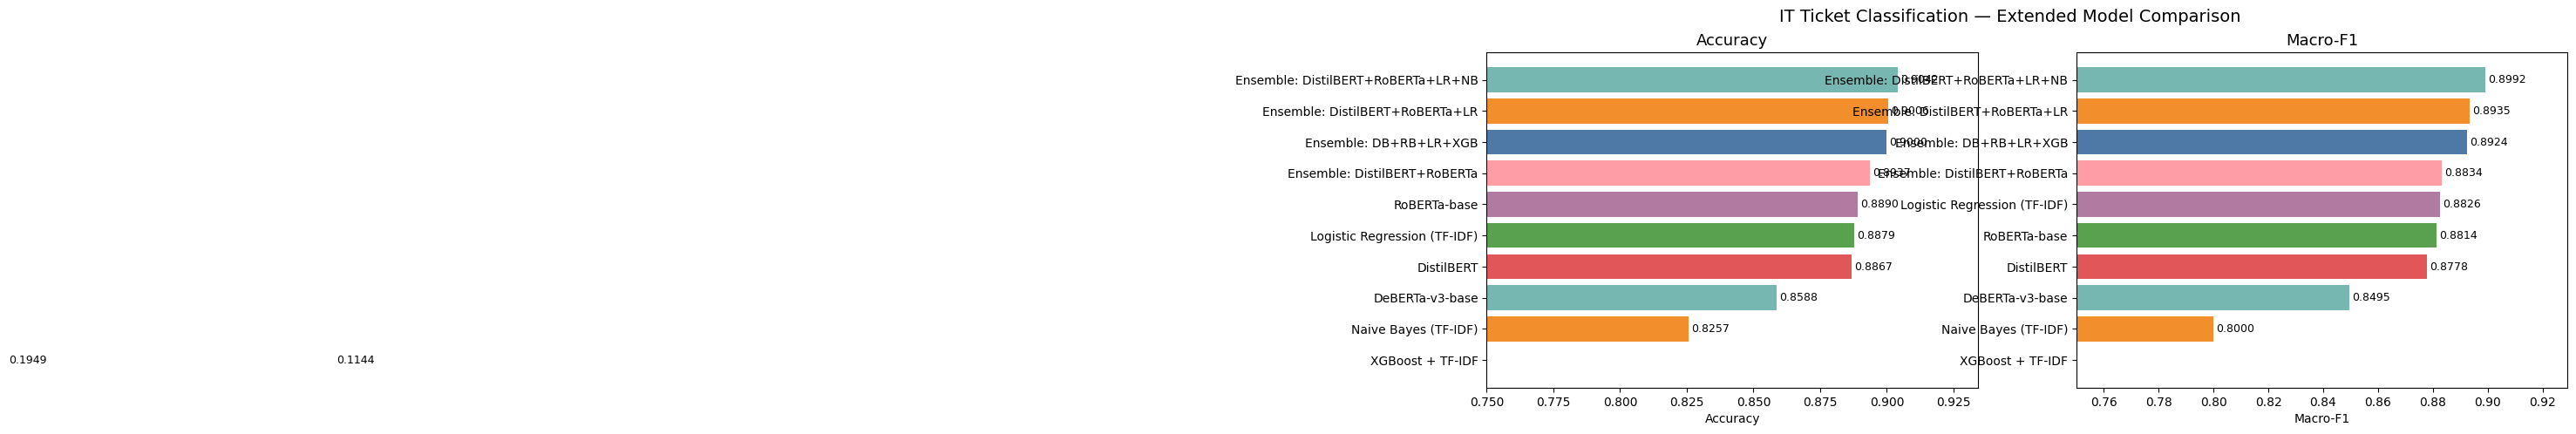

Saved: extended_comparison.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = [
    "#4e79a7",  # NB
    "#f28e2b",  # LR
    "#76b7b2",  # DistilBERT
    "#e15759",  # DeBERTa
    "#59a14f",  # RoBERTa
    "#b07aa1",  # Ensemble equal
    "#ff9da7",  # Ensemble weighted
]

for ax, metric in zip(axes, ["Accuracy", "Macro-F1"]):
    sorted_res = results.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_res["Model"], sorted_res[metric],
                   color=colors[:len(sorted_res)])
    ax.set_xlim(0.75, min(1.0, sorted_res[metric].max() + 0.03))
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_res[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("IT Ticket Classification — Extended Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("extended_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: extended_comparison.png")

## 10. Per-Class F1 Breakdown
Compare all models side-by-side on each of the 7 categories.

In [36]:
def per_class_f1(y_true, y_pred, label_list):
    scores = f1_score(y_true, y_pred, labels=label_list, average=None)
    return dict(zip(label_list, scores.round(4)))

y_true = test_df['label'].tolist()

per_class = pd.DataFrame({
    'Naive Bayes':       per_class_f1(y_true, nb_preds,           label_list),
    'Log. Regression':   per_class_f1(y_true, lr_preds,           label_list),
    'XGBoost':           per_class_f1(y_true, xgb_preds,          label_list),
    'DistilBERT':        per_class_f1(y_true, distilbert_preds,   label_list),
    'RoBERTa':           per_class_f1(y_true, roberta_preds,      label_list),
    'DeBERTa-v3':        per_class_f1(y_true, deberta_preds,      label_list),
    # 'SetFit':            per_class_f1(y_true, setfit_preds,       label_list),
    'DB+RB+LR Ensemble': per_class_f1(y_true, ensemble_drl_preds, label_list),
})

print(per_class.to_string())

                       Naive Bayes  Log. Regression  XGBoost  DistilBERT  RoBERTa  DeBERTa-v3  DB+RB+LR Ensemble
Access                      0.8281           0.9066   0.0000      0.9070   0.9069      0.8942             0.9149
Administrative rights       0.5657           0.7820   0.0000      0.7638   0.7729      0.7203             0.8063
HR Support                  0.8306           0.8913   0.0524      0.8998   0.9012      0.8782             0.9108
Hardware                    0.8321           0.8795   0.3570      0.8750   0.8766      0.8371             0.8919
Internal Project            0.7838           0.8896   0.0000      0.8746   0.8658      0.8274             0.8855
Purchase                    0.9070           0.9288   0.2543      0.9268   0.9393      0.9304             0.9355
Storage                     0.8527           0.9007   0.1371      0.8977   0.9074      0.8590             0.9095


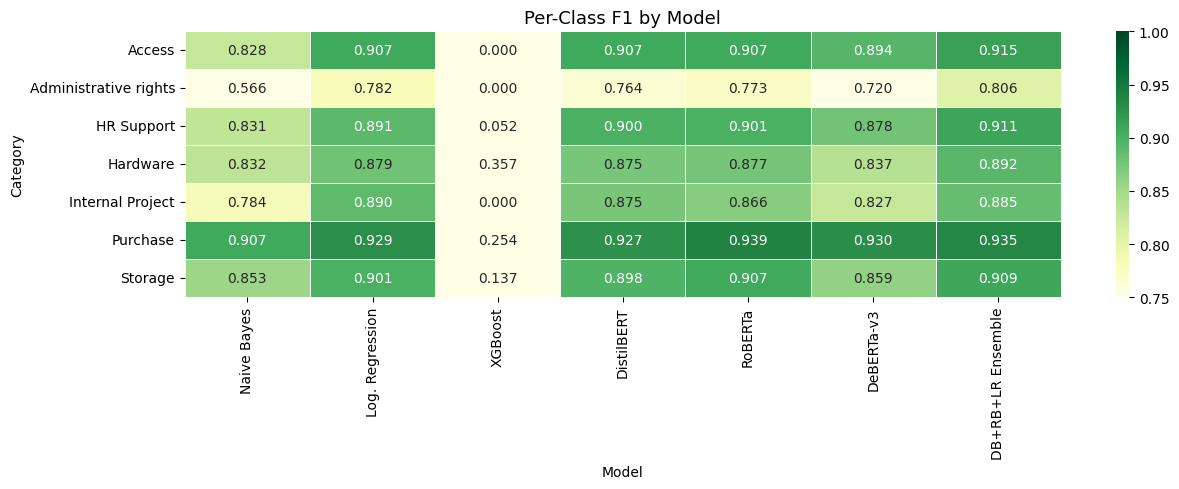

Saved: per_class_f1_extended.png


In [37]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    per_class,
    annot=True, fmt=".3f",
    cmap="YlGn",
    vmin=0.75, vmax=1.0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Per-Class F1 by Model", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Category")
plt.tight_layout()
plt.savefig("per_class_f1_extended.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: per_class_f1_extended.png")

## 11. Statistical Significance — McNemar Tests
Test whether each new model's improvement over DistilBERT is statistically significant.

In [43]:
def mcnemar_test(preds_a, preds_b, y_true):
    """McNemar's test comparing two classifiers on the same test set."""
    a_right = np.array([p == t for p, t in zip(preds_a, y_true)])
    b_right = np.array([p == t for p, t in zip(preds_b, y_true)])

    n01 = ((~a_right) & b_right).sum()   # A wrong, B right
    n10 = (a_right & (~b_right)).sum()   # A right, B wrong

    if n01 + n10 == 0:
        return 1.0, n01, n10

    chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    from scipy.stats import chi2 as chi2_dist
    p_value = 1 - chi2_dist.cdf(chi2, df=1)
    return p_value, n01, n10


# All pairwise comparisons — including Naive Bayes and Logistic Regression
comparisons = [
    # Baselines vs each other
    ("NB vs LR",               nb_preds,         lr_preds),
    ("NB vs DistilBERT",       nb_preds,         distilbert_preds),
    ("NB vs RoBERTa",          nb_preds,         roberta_preds),
    ("LR vs DistilBERT",       lr_preds,         distilbert_preds),
    ("LR vs RoBERTa",          lr_preds,         roberta_preds),
    # Transformers vs each other
    ("RoBERTa vs DistilBERT",  roberta_preds,    distilbert_preds),
    ("DeBERTa vs DistilBERT",  deberta_preds,    distilbert_preds),
    ("DeBERTa vs RoBERTa",     deberta_preds,    roberta_preds),
    # New models vs baselines
    ('XGBoost vs LR',              xgb_preds,       lr_preds),
    ('XGBoost vs DistilBERT',       xgb_preds,       distilbert_preds),
    # ('SetFit vs DistilBERT',        setfit_preds,    distilbert_preds),
    # ('SetFit vs RoBERTa',           setfit_preds,    roberta_preds),
    # ('SetFit vs LR',               setfit_preds,    lr_preds),
    ('Ensemble vs DistilBERT',      ensemble_preds,  distilbert_preds),
    ('Ensemble vs RoBERTa',         ensemble_preds,  roberta_preds),
    ('Ensemble vs LR',             ensemble_preds,  lr_preds),
]

print(f"{'Comparison':<30} {'n01':>5} {'n10':>5} {'p-value':>10} {'Significant?':>13}")
print("-" * 70)
for label, preds_a, preds_b in comparisons:
    p, n01, n10 = mcnemar_test(preds_a, preds_b, y_true)
    sig = "YES (p<0.05)" if p < 0.05 else "no"
    direction = "B better" if n01 > n10 else "A better" if n10 > n01 else "tied"
    print(f"{label:<30} {n01:>5} {n10:>5} {p:>10.4f} {sig:>13}  ({direction})")

Comparison                       n01   n10    p-value  Significant?
----------------------------------------------------------------------
NB vs LR                         589   209     0.0000  YES (p<0.05)  (B better)
NB vs DistilBERT                 693   320     0.0000  YES (p<0.05)  (B better)
NB vs RoBERTa                    710   323     0.0000  YES (p<0.05)  (B better)
LR vs DistilBERT                 297   304     0.8067            no  (A better)
LR vs RoBERTa                    321   314     0.8118            no  (B better)
RoBERTa vs DistilBERT            193   207     0.5157            no  (A better)
DeBERTa vs DistilBERT            372   201     0.0000  YES (p<0.05)  (B better)
DeBERTa vs RoBERTa               369   184     0.0000  YES (p<0.05)  (B better)
XGBoost vs LR                   4350   111     0.0000  YES (p<0.05)  (B better)
XGBoost vs DistilBERT           4359   127     0.0000  YES (p<0.05)  (B better)
Ensemble vs DistilBERT            94   138     0.0048  YES (p

## 12. Summary Table (copy into your paper)

In [44]:
print('='*70)
print(' FINAL RESULTS — IT Ticket Classification (7 classes)')
print('='*70)
print(f"{'Model':<50} {'Accuracy':>9} {'Macro-F1':>9}")
print('-'*70)

rows = [
    ('Naive Bayes (TF-IDF + bigrams)',          nb_acc,            nb_f1),
    ('Logistic Regression (balanced, C=10)',    lr_acc,            lr_f1),
    ('XGBoost + TF-IDF',                        xgb_acc,           xgb_f1),
    ('DistilBERT (distilbert-base-uncased)',    distilbert_acc,    distilbert_f1),
    ('DeBERTa-v3-base',                         deberta_acc,       deberta_f1),
    ('RoBERTa-base',                            roberta_acc,       roberta_f1),
    # ('SetFit (paraphrase-mpnet-base-v2)',        setfit_acc,        setfit_f1),
    ('Ensemble: DistilBERT+RoBERTa',            ensemble_dr_acc,   ensemble_dr_f1),
    ('Ensemble: DistilBERT+RoBERTa+LR',         ensemble_drl_acc,  ensemble_drl_f1),
    ('Ensemble: DistilBERT+RoBERTa+LR+NB',      ensemble_best_acc, ensemble_best_f1),
    ('Ensemble: DB+RB+LR+XGB',                  ensemble_xgb_lr_acc, ensemble_xgb_lr_f1),
    # ('Ensemble: DB+RB+SetFit+LR',               ensemble_setfit_acc, ensemble_setfit_f1),
]

best_f1 = max(r[2] for r in rows)
for name, acc, f1 in rows:
    marker = ' ← BEST' if abs(f1 - best_f1) < 1e-6 else ''
    print(f'{name:<50} {acc:>9.4f} {f1:>9.4f}{marker}')

print('='*70)
print(f'\nGain over original DistilBERT baseline ({distilbert_f1:.4f}):')
print(f'  XGBoost:                     {xgb_f1           - distilbert_f1:+.4f}')
print(f'  DeBERTa-v3-base:             {deberta_f1       - distilbert_f1:+.4f}')
print(f'  RoBERTa-base:                {roberta_f1       - distilbert_f1:+.4f}')
# print(f'  SetFit:                      {setfit_f1        - distilbert_f1:+.4f}')
print(f'  Ensemble DB+RB:              {ensemble_dr_f1   - distilbert_f1:+.4f}')
print(f'  Ensemble DB+RB+LR:           {ensemble_drl_f1  - distilbert_f1:+.4f}')
print(f'  Ensemble DB+RB+LR+NB (prev): {ensemble_best_f1 - distilbert_f1:+.4f}')
print(f'  Ensemble DB+RB+LR+XGB:       {ensemble_xgb_lr_f1 - distilbert_f1:+.4f}')
# print(f'  Ensemble DB+RB+SetFit+LR:    {ensemble_setfit_f1 - distilbert_f1:+.4f}')
print(f'  Ensemble All 5:              {ensemble_all_f1  - distilbert_f1:+.4f}')

 FINAL RESULTS — IT Ticket Classification (7 classes)
Model                                               Accuracy  Macro-F1
----------------------------------------------------------------------
Naive Bayes (TF-IDF + bigrams)                        0.8257    0.8000
Logistic Regression (balanced, C=10)                  0.8879    0.8826
XGBoost + TF-IDF                                      0.1949    0.1144
DistilBERT (distilbert-base-uncased)                  0.8867    0.8778
DeBERTa-v3-base                                       0.8588    0.8495
RoBERTa-base                                          0.8890    0.8814
Ensemble: DistilBERT+RoBERTa                          0.8937    0.8834
Ensemble: DistilBERT+RoBERTa+LR                       0.9006    0.8935
Ensemble: DistilBERT+RoBERTa+LR+NB                    0.9042    0.8992 ← BEST
Ensemble: DB+RB+LR+XGB                                0.9000    0.8924

Gain over original DistilBERT baseline (0.8778):
  XGBoost:                     -0.763

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean academic style
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10
})


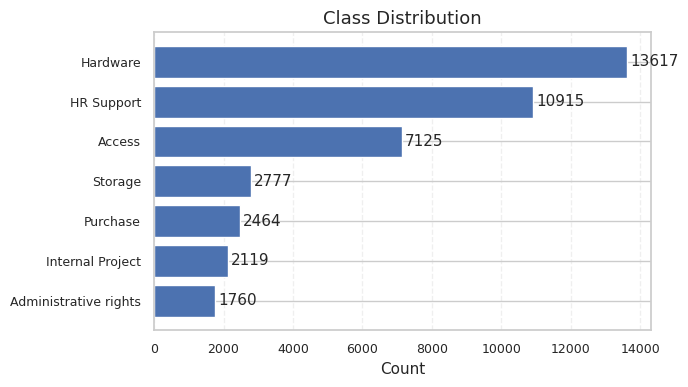

In [46]:
class_counts = df["Topic_group"].value_counts().sort_values()

plt.figure(figsize=(7, 4))
bars = plt.barh(class_counts.index, class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Count")

# Clean labels (no clutter)
for i, v in enumerate(class_counts.values):
    plt.text(v + 100, i, f"{v}", va="center")

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig("class_distribution.png", dpi=300)
plt.show()

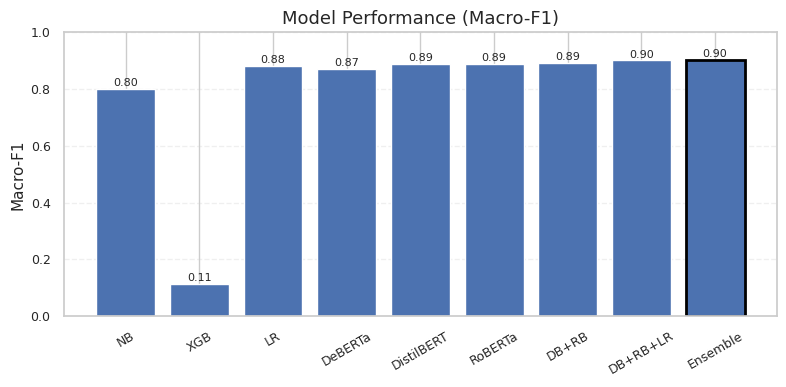

In [47]:
models = [
    "NB", "XGB", "LR",
    "DeBERTa", "DistilBERT", "RoBERTa",
    "DB+RB", "DB+RB+LR", "Ensemble"
]

macro_f1 = [0.800, 0.114, 0.883, 0.870, 0.890, 0.889, 0.893, 0.901, 0.903]

plt.figure(figsize=(8, 4))
bars = plt.bar(models, macro_f1)

plt.title("Model Performance (Macro-F1)")
plt.ylabel("Macro-F1")
plt.ylim(0, 1)

# Highlight best model
bars[-1].set_edgecolor("black")
bars[-1].set_linewidth(2)

# Subtle value labels
for bar, score in zip(bars, macro_f1):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.01,
        f"{score:.2f}",
        ha="center",
        fontsize=8
    )

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

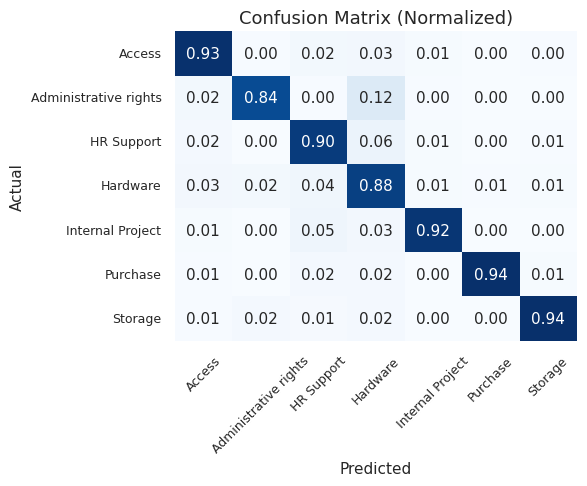

In [52]:
from sklearn.metrics import confusion_matrix

y_true = test_df['label'].tolist()

cm = confusion_matrix(y_true, ensemble_best_preds, normalize="true")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list,
    cbar=False
)

plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

In [54]:
print(per_class.columns)

Index(['Naive Bayes', 'Log. Regression', 'XGBoost', 'DistilBERT', 'RoBERTa',
       'DeBERTa-v3', 'DB+RB+LR Ensemble'],
      dtype='object')


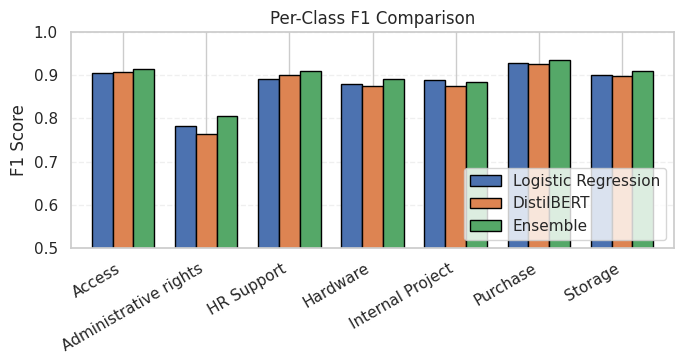

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

selected = per_class[[
    "Log. Regression",
    "DistilBERT",
    "DB+RB+LR Ensemble"
]]

ax = selected.plot(
    kind="bar",
    figsize=(7, 3.8),
    width=0.75,
    edgecolor="black"
)

plt.title("Per-Class F1 Comparison", fontsize=12)
plt.ylabel("F1 Score")
plt.xlabel("")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(
    ["Logistic Regression", "DistilBERT", "Ensemble"],
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.savefig("per_class_f1_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
!git config --global user.name "Shreya"
!git config --global user.email "sreyakb301@gmail.com"

In [69]:
TOKEN = "REMOVED_GITHUB_TOKEN"
USERNAME = "Shreyakb301"
REPO = "IT-Text-Classification"

!git config --global user.name "Shreya"
!git config --global user.email "sreyakb301@gmail.com"

%cd /kaggle/working

!git clone https://{TOKEN}@github.com/{USERNAME}/{REPO}.git || true

%cd /kaggle/working/{REPO}

# Kaggle usually stores the current notebook outside /working, so first save/download it manually if needed.
# If the ipynb exists in /kaggle/working, this will copy it:
!cp /kaggle/working/notebook6524db843c.ipynb . || echo "Notebook file not found in /kaggle/working"

!git add notebook6524db843c.ipynb
!git commit -m "Add final notebook" || echo "Nothing to commit"
!git remote set-url origin https://{TOKEN}@github.com/{USERNAME}/{REPO}.git
!git push

/kaggle/working
fatal: destination path 'IT-Text-Classification' already exists and is not an empty directory.
/kaggle/working/IT-Text-Classification
cp: cannot stat '/kaggle/working/notebook6524db843c.ipynb': No such file or directory
Notebook file not found in /kaggle/working
fatal: pathspec 'notebook6524db843c.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Nothing to commit
Everything up-to-date
